<a href="https://colab.research.google.com/github/martirossi/AppliedML2026_mr/blob/main/classification_lighGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# ============================================
# LightGBM electron classification with:
# - Feature selection via correlation with target
# - 5-fold cross-validation
# - Early stopping to avoid overfitting
# - Training and validation loss plots
# - CSV outputs:
#     1) Classification_MartinaRossi_LightGBM.csv
#     2) Classification_MartinaRossi_LightGBM_VariableList.csv
# ============================================

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.metrics import log_loss

# ------------------------------------------------
# 1. Load your dataset
# ------------------------------------------------
# Assumption:
# - The dataset is in a CSV file called "dataset1.csv"
# - It contains:
#     * 140 feature columns (numerical)
#     * 1 target column: "p_Truth_isElectron" (0 or 1)
#     * optionally an ID column, e.g. "EventID" (if you have it)
# Adjust the file name and column names as needed.

data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AppML_InitialProject_train.csv")

# If you have an ID column, keep it aside (optional)
id_col = None
for col in data.columns:
    if col.lower() in ["eventid", "id"]:
        id_col = col
        break

if id_col is not None:
    ids = data[id_col].values
else:
    # If no ID column, create a simple index-based ID
    ids = np.arange(len(data))

# Target variable
target_col = "p_Truth_isElectron"
y = data[target_col].values

# Feature columns: all columns except target and ID (if present)
feature_cols = [c for c in data.columns if c not in [target_col, id_col]]

# ------------------------------------------------
# 2. Feature selection via correlation with target
# ------------------------------------------------
# We compute the absolute Pearson correlation between each feature and the target.
# Then we select the top 15 most correlated features.

correlations = {}
for col in feature_cols:
    # Compute correlation between feature and target
    corr = np.corrcoef(data[col].values, y)[0, 1]
    correlations[col] = abs(corr)

# Sort features by absolute correlation (descending)
sorted_features = sorted(correlations.items(), key=lambda x: x[1], reverse=True)

# Select top 15 features
top_15_features = [f[0] for f in sorted_features[:15]]

print("Selected 15 features based on correlation with target:")
for f in top_15_features:
    print(f)

# Save the selected variable list to CSV
varlist_df = pd.DataFrame({"FeatureName": top_15_features})
varlist_df.to_csv("Classification_MartinaRossi_LightGBM_VariableList.csv", index=False)





Selected 15 features based on correlation with target:
pX_MultiLepton
p_TRTPID
pX_f1core
p_Eratio
pX_etcone30
pX_etcone40
pX_e132
pX_emaxs1
pX_etcone20
pX_topoetcone30
pX_topoetcone40
p_etcone30
p_etcone40
pX_topoetcone20
p_etcone20


In [17]:
# ------------------------------------------------
# 3. Prepare data with the 15 selected features (correlation + MI + redundancy removal + forced features)
# ------------------------------------------------

from sklearn.feature_selection import mutual_info_classif

# --- 3.0 Define two strong features to force into the selection ---
forced_features = ["p_Eratio", "p_Rhad"]   # <-- CHANGE THESE if needed

# --- 3.1 Compute Pearson correlation with the target ---
corr_scores = {}
for col in feature_cols:
    corr = np.corrcoef(data[col].values, y)[0, 1]
    corr_scores[col] = abs(corr)

# --- 3.2 Compute Mutual Information with the target ---
mi_scores = mutual_info_classif(data[feature_cols], y, random_state=42)
mi_scores = dict(zip(feature_cols, mi_scores))

# --- 3.3 Normalize both scores ---
corr_norm = {k: v / max(corr_scores.values()) for k, v in corr_scores.items()}
mi_norm = {k: v / max(mi_scores.values()) for k, v in mi_scores.items()}

# --- 3.4 Combine correlation + MI ---
combined_score = {f: corr_norm[f] + mi_norm[f] for f in feature_cols}

# --- 3.5 Sort features by combined score ---
sorted_features = sorted(combined_score.items(), key=lambda x: x[1], reverse=True)

# --- 3.6 Remove redundant features (correlation > 0.90) but ALWAYS keep forced features ---
selected = []

# First: add forced features (if they exist in the dataset)
for f in forced_features:
    if f in feature_cols:
        selected.append(f)

# Then: fill remaining slots with best-ranked non-redundant features
for f, score in sorted_features:
    if f in selected:
        continue  # skip forced features already added

    # Check redundancy
    keep = True
    for s in selected:
        if abs(np.corrcoef(data[f], data[s])[0, 1]) > 0.90:
            keep = False
            break

    if keep:
        selected.append(f)

    if len(selected) == 15:
        break

top_15_features = selected

print("Selected 15 features (including forced ones):")
for f in top_15_features:
    print(f)

# --- 3.7 Prepare X matrix with the selected 15 features ---
X = data[top_15_features].values



Selected 15 features (including forced ones):
p_Eratio
p_Rhad
pX_MultiLepton
p_etcone20
pX_topoetcone20
pX_etcone40
p_Rhad1
pX_emaxs1
p_TRTPID
pX_neflowisol30
pX_f1core
pX_ehad1
pX_deltaEta1
p_deltaEta1
p_ptPU30


In [18]:
# ------------------------------------------------
# 4. 5-fold cross-validation setup
# ------------------------------------------------
# We will:
# - Split the data into 5 folds
# - For each fold:
#     * Train on 4 folds
#     * Validate on 1 fold
# - Use early stopping:
#     num_boost_round = 500
#     early_stopping_rounds = 50
# - Store:
#     * validation predictions
#     * training and validation loss per iteration (for plotting)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# To store out-of-fold predictions (for all samples)
oof_preds = np.zeros(len(data))

# To store training and validation loss curves (averaged across folds)
# We will store per-iteration losses for each fold, then average.
train_loss_per_fold = []
valid_loss_per_fold = []

# LightGBM parameters
params = {
    "objective": "binary",          # binary classification
    "metric": "binary_logloss",     # Binary Cross Entropy (LogLoss)
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    "feature_fraction": 1.0,
    "bagging_fraction": 1.0,
    "bagging_freq": 0,
    "verbose": -1
}

num_boost_round = 500
early_stopping_rounds = 50

fold_idx = 1
for train_index, valid_index in kf.split(X, y):
    print(f"\n===== Fold {fold_idx} =====")

    X_train, X_valid = X[train_index], X[valid_index]
    y_train, y_valid = y[train_index], y[valid_index]

    # Create LightGBM datasets
    lgb_train = lgb.Dataset(X_train, label=y_train, feature_name=top_15_features)
    lgb_valid = lgb.Dataset(X_valid, label=y_valid, feature_name=top_15_features)

    # Train the model with early stopping
    evals_result = {}  # to store training history

    model = lgb.train(
        params=params,
        train_set=lgb_train,
        valid_sets=[lgb_train, lgb_valid],
        valid_names=["train", "valid"],
        num_boost_round=num_boost_round,
        callbacks=[
            lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=False),
            lgb.callback.record_evaluation(evals_result),
            lgb.log_evaluation(period=50) # Fixed: Use callback for verbose_eval
        ]
    )

    # Best iteration for this fold
    best_iter = model.best_iteration
    print(f"Best iteration for fold {fold_idx}: {best_iter}")

    # Store validation predictions (probabilities between 0 and 1)
    oof_preds[valid_index] = model.predict(X_valid, num_iteration=best_iter)

    # Extract loss curves for this fold
    train_loss = evals_result["train"]["binary_logloss"]
    valid_loss = evals_result["valid"]["binary_logloss"]

    train_loss_per_fold.append(train_loss)
    valid_loss_per_fold.append(valid_loss)

    fold_idx += 1


===== Fold 1 =====
[50]	train's binary_logloss: 0.158062	valid's binary_logloss: 0.16429
[100]	train's binary_logloss: 0.132679	valid's binary_logloss: 0.14554
[150]	train's binary_logloss: 0.122521	valid's binary_logloss: 0.143092
[200]	train's binary_logloss: 0.115123	valid's binary_logloss: 0.142484
[250]	train's binary_logloss: 0.109034	valid's binary_logloss: 0.14253
Best iteration for fold 1: 218

===== Fold 2 =====
[50]	train's binary_logloss: 0.158144	valid's binary_logloss: 0.162374
[100]	train's binary_logloss: 0.132916	valid's binary_logloss: 0.14375
[150]	train's binary_logloss: 0.122582	valid's binary_logloss: 0.14174
[200]	train's binary_logloss: 0.115238	valid's binary_logloss: 0.14163
Best iteration for fold 2: 169

===== Fold 3 =====
[50]	train's binary_logloss: 0.157978	valid's binary_logloss: 0.164307
[100]	train's binary_logloss: 0.132505	valid's binary_logloss: 0.146372
[150]	train's binary_logloss: 0.122312	valid's binary_logloss: 0.144582
[200]	train's binary_lo

In [19]:
# ------------------------------------------------
# 5. Compute overall LogLoss on out-of-fold predictions
# ------------------------------------------------
overall_logloss = log_loss(y, oof_preds)
print(f"\nOverall OOF LogLoss (5-fold CV): {overall_logloss:.6f}")


Overall OOF LogLoss (5-fold CV): 0.142863


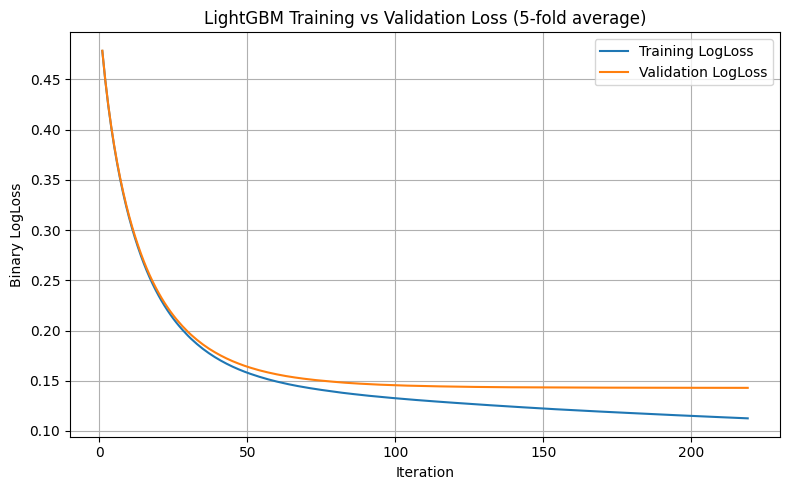

In [20]:
# ------------------------------------------------
# 6. Plot training and validation loss curves
# ------------------------------------------------
# The folds may have different best_iteration lengths due to early stopping.
# To average them, we can:
# - Find the minimum length across folds
# - Truncate all curves to that length
min_len_train = min(len(curve) for curve in train_loss_per_fold)
min_len_valid = min(len(curve) for curve in valid_loss_per_fold)
min_len = min(min_len_train, min_len_valid)

# Truncate and average
avg_train_loss = np.mean([curve[:min_len] for curve in train_loss_per_fold], axis=0)
avg_valid_loss = np.mean([curve[:min_len] for curve in valid_loss_per_fold], axis=0)

iterations = np.arange(1, min_len + 1)

plt.figure(figsize=(8, 5))
plt.plot(iterations, avg_train_loss, label="Training LogLoss")
plt.plot(iterations, avg_valid_loss, label="Validation LogLoss")
plt.xlabel("Iteration")
plt.ylabel("Binary LogLoss")
plt.title("LightGBM Training vs Validation Loss (5-fold average)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("LightGBM_Loss_Curves_MartinaRossi.png", dpi=200);
plt.show()


In [24]:
# ------------------------------------------------
# 7. Save final outputs (predictions + variable list)
# ------------------------------------------------

# 7.1 Load the test dataset
test_path = "/content/drive/MyDrive/Colab Notebooks/AppML_InitialProject_test_classification.csv"
test_data = pd.read_csv(test_path)

# Detect ID column if present
test_id_col = None
for col in test_data.columns:
    if col.lower() in ["eventid", "id"]:
        test_id_col = col
        break

if test_id_col is not None:
    test_ids = test_data[test_id_col].values
else:
    test_ids = np.arange(len(test_data))

# Prepare test matrix with the SAME 15 features
X_test = test_data[top_15_features].values

# Train final model on ALL training data using the average best iteration
final_train = lgb.Dataset(X, label=y)
avg_best_iter = int(np.mean([len(v) for v in valid_loss_per_fold]))

final_model = lgb.train(
    params=params,
    train_set=final_train,
    num_boost_round=avg_best_iter
)

# Predict probabilities on the test set
test_preds = final_model.predict(X_test)

# ------------------------------------------------
# Save file 1: predictions
# ------------------------------------------------
submission_df = pd.DataFrame({
    "ID": test_ids,
    "Predicted_Probability": test_preds
})

submission_df.to_csv("Classification_MartinaRossi_LightGBM.csv", index=False)

# ------------------------------------------------
# Save file 2: variable list
# ------------------------------------------------
varlist_df = pd.DataFrame({"FeatureName": top_15_features})
varlist_df.to_csv("Classification_MartinaRossi_LightGBM_VariableList.csv", index=False)

print("\nSaved files:")
print(" - Classification_MartinaRossi_LightGBM.csv")
print(" - Classification_MartinaRossi_LightGBM_VariableList.csv")





Saved files:
 - Classification_MartinaRossi_LightGBM.csv
 - Classification_MartinaRossi_LightGBM_VariableList.csv
